# Feature Extraction Showcase

This notebook demonstrates the end-to-end feature engineering pipeline for speech pathology classification.

It covers:
- running extraction via `FeatureOptions`
- inspecting the generated multi-table outputs
- basic quality checks and quick exploratory plots

In [1]:
import sys
from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sys.path.append("..")

from src.features import FeatureOptions, load_feature_tables, summarize_feature_tables

In [2]:
# Configure extraction/loading behavior
opts = FeatureOptions(
    prefix=Path(".."),
    include_splits=True,
    random_seed=42,
    max_samples_per_class=200,  # Speed-up for testing; set None for full run.
    selected_token="a_n"
 )

opts

FeatureOptions(prefix=WindowsPath('..'), input_manifest=WindowsPath('data/processed/manifests/dataset_manifest.csv'), output_core=WindowsPath('data/processed/features/sample_core.csv'), output_acoustic=WindowsPath('data/processed/features/acoustic_features.csv'), output_multifractal=WindowsPath('data/processed/features/multifractal_features.csv'), output_opensmile=WindowsPath('data/processed/features/opensmile_features.csv'), output_splits=WindowsPath('data/processed/features/sample_splits.csv'), output_summary_json=WindowsPath('data/processed/features/feature_summary.json'), include_splits=True, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15, random_seed=42, num_workers=None, max_samples_per_class=200, balance_healthy=False, normalize_audio=True, target_sample_rate=22050, selected_token='a_n', mfdfa_order=1, mfdfa_q_min=-5.0, mfdfa_q_max=5.0, mfdfa_q_step=1.0, mfdfa_num_scales=20)

In [3]:
# Build missing tables if needed, otherwise load cached outputs
tables = load_feature_tables(options=opts, build_if_missing=True, save_if_built=True)
summary = summarize_feature_tables(tables)
summary

Extracting features:   0%|          | 0/1143 [00:00<?, ?sample/s]

{'num_samples': 1143,
 'num_acoustic_rows': 1143,
 'num_multifractal_rows': 1143,
 'num_opensmile_rows': 1143,
 'feature_status_counts': {'ok': 1143},
 'acoustic_status_counts': {'ok': 1143},
 'multifractal_status_counts': {'ok': 1143},
 'opensmile_status_counts': {'ok': 1143},
 'split_counts': {'train': 779, 'val': 202, 'test': 162}}

## Inspect generated tables

The pipeline creates separate tables for metadata/core status, acoustic features, multifractal features, and splits.

In [4]:
for name, df in tables.items():
    print(f"{name}: shape={df.shape}")

core_df = tables["core"]
acoustic_df = tables["acoustic"]
multifractal_df = tables["multifractal"]
opensmile_df = tables["opensmile"]
splits_df = tables.get("splits", pd.DataFrame())

core: shape=(1143, 18)
acoustic: shape=(1143, 87)
multifractal: shape=(1143, 17)
opensmile: shape=(1143, 91)
splits: shape=(1143, 3)


In [5]:
core_df.head()

,sample_key,duplicate_class_key,recording_id,speaker_id,pathology_de,pathology_en,is_healthy,modality,token,sex,is_overlap_speaker,is_overlap_speaker_id,wav_path,feature_status,feature_error,audio_sample_rate,audio_num_samples,audio_duration_seconds
0,Funktionelle Dysphonie::350::vowels::a_n,Funktionelle Dysphonie::350,350,1339,Funktionelle Dysphonie,functional dysphonia,False,vowels,a_n,w,False,False,..\data\processed\wav\Funktionelle Dysphonie\3...,ok,None,22050,16269,0.737823
1,Funktionelle Dysphonie::351::vowels::a_n,Funktionelle Dysphonie::351,351,1340,Funktionelle Dysphonie,functional dysphonia,False,vowels,a_n,w,False,True,..\data\processed\wav\Funktionelle Dysphonie\3...,ok,None,22050,39029,1.770023
2,Funktionelle Dysphonie::631::vowels::a_n,Funktionelle Dysphonie::631,631,1388,Funktionelle Dysphonie,functional dysphonia,False,vowels,a_n,m,False,False,..\data\processed\wav\Funktionelle Dysphonie\6...,ok,None,22050,32340,1.466667
3,Funktionelle Dysphonie::634::vowels::a_n,Funktionelle Dysphonie::634,634,1391,Funktionelle Dysphonie,functional dysphonia,False,vowels,a_n,m,False,False,..\data\processed\wav\Funktionelle Dysphonie\6...,ok,None,22050,33747,1.530476
4,Funktionelle Dysphonie::718::vowels::a_n,Funktionelle Dysphonie::718,718,1410,Funktionelle Dysphonie,functional dysphonia,False,vowels,a_n,m,False,False,..\data\processed\wav\Funktionelle Dysphonie\7...,ok,None,22050,37376,1.695057


In [6]:
acoustic_df.head()

,sample_key,acoustic_status,acoustic_error,ac_time_energy,ac_time_abs_mean,ac_time_peak,ac_time_crest_factor,ac_rms_mean,ac_rms_std,ac_rms_min,...,ac_mfcc12_delta_mean,ac_mfcc12_delta_std,ac_mfcc13_mean,ac_mfcc13_std,ac_mfcc13_delta_mean,ac_mfcc13_delta_std,ac_f0_mean,ac_f0_std,ac_f0_min,ac_f0_max
0,Funktionelle Dysphonie::350::vowels::a_n,ok,None,0.098943,0.243461,1.0,3.179132,0.298907,0.085990,0.121809,...,-0.211483,0.848803,-17.839901,8.094102,0.700468,0.895577,225.262411,2.632202,217.045325,227.768667
1,Funktionelle Dysphonie::351::vowels::a_n,ok,None,0.076069,0.214293,1.0,3.625728,0.269528,0.046021,0.176159,...,-0.132527,0.371746,-10.118921,4.043226,0.111917,0.412705,169.206927,1.721647,165.710473,172.937798
2,Funktionelle Dysphonie::631::vowels::a_n,ok,None,0.129802,0.298316,1.0,2.775619,0.354310,0.040888,0.208705,...,0.006335,0.728674,8.638985,2.994691,-0.039316,0.483111,104.361644,3.397676,96.022340,109.275040
3,Funktionelle Dysphonie::634::vowels::a_n,ok,None,0.088321,0.230636,1.0,3.364859,0.293632,0.030110,0.212830,...,-0.143852,0.318999,-6.444102,2.642589,0.110945,0.353236,156.909474,1.136372,155.489509,160.150314
4,Funktionelle Dysphonie::718::vowels::a_n,ok,None,0.087890,0.224211,1.0,3.373100,0.292613,0.022245,0.184290,...,0.131629,0.739271,-6.758677,4.298935,-0.142373,0.642266,130.392017,1.540906,126.323137,133.603871


In [7]:
multifractal_df.head()

,sample_key,mf_status,mf_error,mf_hq_mean,mf_hq_std,mf_hq_min,mf_hq_max,mf_tau_mean,mf_tau_std,mf_alpha_mean,mf_alpha_std,mf_spectrum_width,mf_spectrum_peak_alpha,mf_spectrum_peak_f,mf_spectrum_asymmetry,mf_num_scales,mf_num_q
0,Funktionelle Dysphonie::350::vowels::a_n,ok,None,0.392926,0.150297,0.210730,0.609425,-1.492475,1.376492,0.417237,0.229663,0.561484,0.275988,0.964770,0.258970,20,10
1,Funktionelle Dysphonie::351::vowels::a_n,ok,None,0.346233,0.120372,0.189060,0.526463,-1.397413,1.202500,0.362507,0.201909,0.521939,0.258477,0.963712,0.348683,20,10
2,Funktionelle Dysphonie::631::vowels::a_n,ok,None,0.441250,0.123791,0.293965,0.645894,-1.404538,1.546775,0.481611,0.216902,0.566938,0.350141,0.976299,0.243465,20,10
3,Funktionelle Dysphonie::634::vowels::a_n,ok,None,0.366574,0.095138,0.237806,0.504514,-1.314549,1.243723,0.373054,0.159011,0.410003,0.428572,0.969949,1.561607,20,10
4,Funktionelle Dysphonie::718::vowels::a_n,ok,None,0.466745,0.155620,0.269741,0.698874,-1.512426,1.622087,0.491702,0.253928,0.644078,0.351746,0.960308,0.320623,20,10


In [8]:
opensmile_df.head()

,sample_key,opensmile_status,opensmile_error,os_F0semitoneFrom27.5Hz_sma3nz_amean,os_F0semitoneFrom27.5Hz_sma3nz_stddevNorm,os_F0semitoneFrom27.5Hz_sma3nz_percentile20.0,os_F0semitoneFrom27.5Hz_sma3nz_percentile50.0,os_F0semitoneFrom27.5Hz_sma3nz_percentile80.0,os_F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2,os_F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope,...,os_slopeUV0-500_sma3nz_amean,os_slopeUV500-1500_sma3nz_amean,os_spectralFluxUV_sma3nz_amean,os_loudnessPeaksPerSec,os_VoicedSegmentsPerSec,os_MeanVoicedSegmentLengthSec,os_StddevVoicedSegmentLengthSec,os_MeanUnvoicedSegmentLength,os_StddevUnvoicedSegmentLength,os_equivalentSoundLevel_dBp
0,Funktionelle Dysphonie::350::vowels::a_n,ok,None,36.446396,0.004107,36.296097,36.494186,36.552311,0.256214,3.390837,...,0.0,0.0,0.0,1.388889,1.492537,0.66,0.0,0.0,0.0,-14.832523
1,Funktionelle Dysphonie::351::vowels::a_n,ok,None,31.489012,0.006479,31.291681,31.480478,31.650621,0.358940,5.817921,...,0.0,0.0,0.0,4.545455,0.584795,1.70,0.0,0.0,0.0,-12.323026
2,Funktionelle Dysphonie::631::vowels::a_n,ok,None,23.095320,0.023835,22.800686,23.185768,23.552200,0.751514,5.230788,...,0.0,0.0,0.0,6.896552,0.719424,1.38,0.0,0.0,0.0,-14.757355
3,Funktionelle Dysphonie::634::vowels::a_n,ok,None,30.149380,0.004346,30.038656,30.125492,30.242844,0.204187,2.102207,...,0.0,0.0,0.0,3.289474,0.684932,1.45,0.0,0.0,0.0,-18.382141
4,Funktionelle Dysphonie::718::vowels::a_n,ok,None,26.973021,0.007818,26.796001,27.005241,27.136238,0.340237,3.412540,...,0.0,0.0,0.0,1.190476,0.617284,1.61,0.0,0.0,0.0,-14.204423


## Join features for modeling

Join on `sample_key` to obtain one model-ready view while preserving separate storage tables.

In [9]:
model_df = core_df.merge(acoustic_df, on="sample_key", how="left")
model_df = model_df.merge(multifractal_df, on="sample_key", how="left")
model_df = model_df.merge(opensmile_df, on="sample_key", how="left")

if not splits_df.empty:
    model_df = model_df.merge(splits_df, on="sample_key", how="left")

model_df.head()

,sample_key,duplicate_class_key,recording_id,speaker_id,pathology_de,pathology_en,is_healthy,modality,token,sex,...,os_spectralFluxUV_sma3nz_amean,os_loudnessPeaksPerSec,os_VoicedSegmentsPerSec,os_MeanVoicedSegmentLengthSec,os_StddevVoicedSegmentLengthSec,os_MeanUnvoicedSegmentLength,os_StddevUnvoicedSegmentLength,os_equivalentSoundLevel_dBp,split,split_seed
0,Funktionelle Dysphonie::350::vowels::a_n,Funktionelle Dysphonie::350,350,1339,Funktionelle Dysphonie,functional dysphonia,False,vowels,a_n,w,...,0.0,1.388889,1.492537,0.66,0.0,0.0,0.0,-14.832523,train,42
1,Funktionelle Dysphonie::351::vowels::a_n,Funktionelle Dysphonie::351,351,1340,Funktionelle Dysphonie,functional dysphonia,False,vowels,a_n,w,...,0.0,4.545455,0.584795,1.70,0.0,0.0,0.0,-12.323026,train,42
2,Funktionelle Dysphonie::631::vowels::a_n,Funktionelle Dysphonie::631,631,1388,Funktionelle Dysphonie,functional dysphonia,False,vowels,a_n,m,...,0.0,6.896552,0.719424,1.38,0.0,0.0,0.0,-14.757355,test,42
3,Funktionelle Dysphonie::634::vowels::a_n,Funktionelle Dysphonie::634,634,1391,Funktionelle Dysphonie,functional dysphonia,False,vowels,a_n,m,...,0.0,3.289474,0.684932,1.45,0.0,0.0,0.0,-18.382141,val,42
4,Funktionelle Dysphonie::718::vowels::a_n,Funktionelle Dysphonie::718,718,1410,Funktionelle Dysphonie,functional dysphonia,False,vowels,a_n,m,...,0.0,1.190476,0.617284,1.61,0.0,0.0,0.0,-14.204423,train,42


In [10]:
print(f"{core_df.columns=}")
print(f"{acoustic_df.columns=}")
print(f"{multifractal_df.columns=}")
print(f"{opensmile_df.columns=}")

core_df.columns=Index(['sample_key', 'duplicate_class_key', 'recording_id', 'speaker_id',
       'pathology_de', 'pathology_en', 'is_healthy', 'modality', 'token',
       'sex', 'is_overlap_speaker', 'is_overlap_speaker_id', 'wav_path',
       'feature_status', 'feature_error', 'audio_sample_rate',
       'audio_num_samples', 'audio_duration_seconds'],
      dtype='str')
acoustic_df.columns=Index(['sample_key', 'acoustic_status', 'acoustic_error', 'ac_time_energy',
       'ac_time_abs_mean', 'ac_time_peak', 'ac_time_crest_factor',
       'ac_rms_mean', 'ac_rms_std', 'ac_rms_min', 'ac_rms_max', 'ac_zcr_mean',
       'ac_zcr_std', 'ac_zcr_min', 'ac_zcr_max', 'ac_spec_centroid_mean',
       'ac_spec_centroid_std', 'ac_spec_centroid_min', 'ac_spec_centroid_max',
       'ac_spec_bandwidth_mean', 'ac_spec_bandwidth_std',
       'ac_spec_bandwidth_min', 'ac_spec_bandwidth_max',
       'ac_spec_rolloff_mean', 'ac_spec_rolloff_std', 'ac_spec_rolloff_min',
       'ac_spec_rolloff_max', 'ac_spec_

In [11]:
# Basic quality checks
status_cols = [c for c in ["feature_status", "acoustic_status", "mf_status"] if c in model_df.columns]
for col in status_cols:
    print(f"\n{col}\n", model_df[col].value_counts(dropna=False))

print("\nMissingness (top 20 columns):")
display(model_df.isna().mean().sort_values(ascending=False).head(20))


feature_status
 feature_status
ok    1143
Name: count, dtype: int64

acoustic_status
 acoustic_status
ok    1143
Name: count, dtype: int64

mf_status
 mf_status
ok    1143
Name: count, dtype: int64

Missingness (top 20 columns):


feature_error            1.0
acoustic_error           1.0
opensmile_error          1.0
mf_error                 1.0
speaker_id               0.0
recording_id             0.0
pathology_de             0.0
pathology_en             0.0
token                    0.0
sex                      0.0
is_healthy               0.0
modality                 0.0
is_overlap_speaker_id    0.0
is_overlap_speaker       0.0
feature_status           0.0
wav_path                 0.0
audio_sample_rate        0.0
audio_num_samples        0.0
sample_key               0.0
duplicate_class_key      0.0
dtype: float64

## Quick exploratory plots

These are lightweight sanity checks to visualize class balance and a few extracted features.

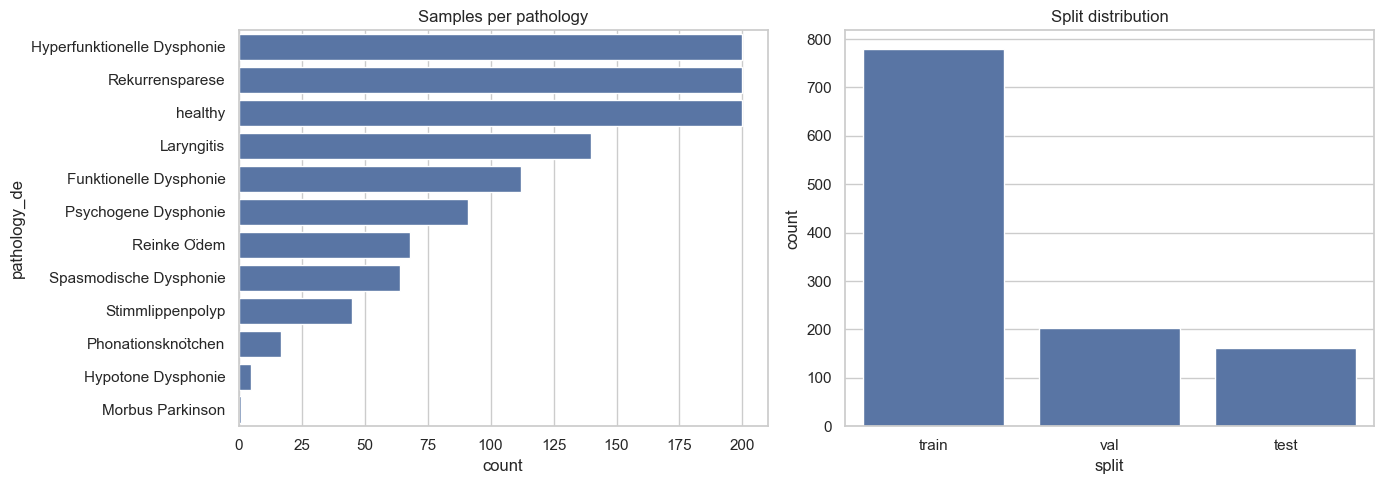

In [12]:
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

if "pathology_de" in model_df.columns:
    order = model_df["pathology_de"].value_counts().index
    sns.countplot(data=model_df, y="pathology_de", order=order, ax=ax[0])
    ax[0].set_title("Samples per pathology")

if "split" in model_df.columns:
    sns.countplot(data=model_df, x="split", order=["train", "val", "test"], ax=ax[1])
    ax[1].set_title("Split distribution")
else:
    ax[1].axis("off")

plt.tight_layout()
plt.show()

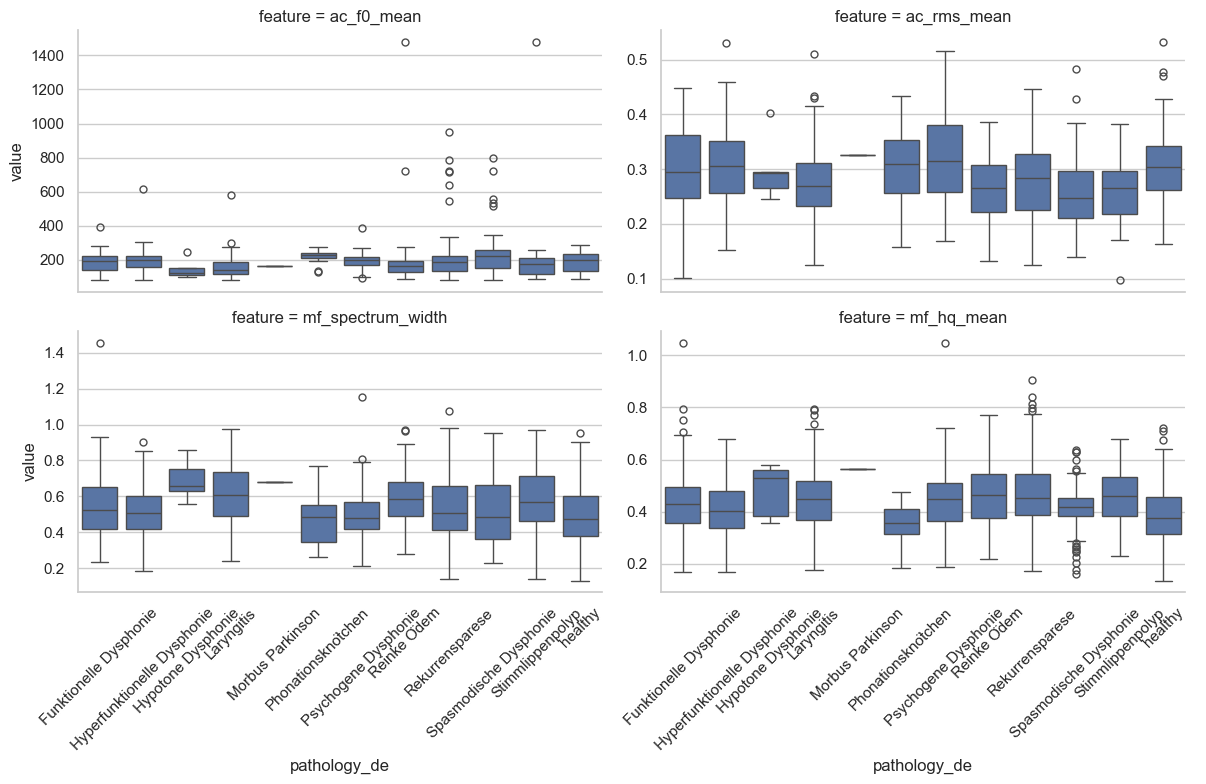

In [13]:
candidate_features = ["ac_f0_mean", "ac_rms_mean", "mf_spectrum_width", "mf_hq_mean"]
existing = [c for c in candidate_features if c in model_df.columns]

if existing and "pathology_de" in model_df.columns:
    plot_df = model_df[["pathology_de", *existing]].copy()
    melted = plot_df.melt(id_vars="pathology_de", var_name="feature", value_name="value")

    g = sns.catplot(
        data=melted,
        x="pathology_de",
        y="value",
        col="feature",
        col_wrap=2,
        kind="box",
        sharey=False,
        height=4,
        aspect=1.5,
    )
    for axis in g.axes.flatten():
        axis.tick_params(axis="x", rotation=45)
    g.fig.tight_layout()
    plt.show()
else:
    print("No candidate columns found yet for feature-by-pathology plot.")

## Persist a model-ready snapshot (optional)

Use this cell if you want a single joined table for rapid prototyping.

In [14]:
out_path = Path("..") / "data" / "processed" / "features" / "model_table_snapshot.csv"
out_path.parent.mkdir(parents=True, exist_ok=True)
model_df.to_csv(out_path, index=False)
print(f"Wrote: {out_path.resolve()}")

Wrote: G:\Projects\multifractal-speech-analysis\data\processed\features\model_table_snapshot.csv
